
Dataset Shape: (1200, 11)
   RPM  Current  Motor_Temperature  Ambient_Temperature  Humidity  Accel_X  \
0   20    0.060              36.38                27.75     68.45    0.112   
1   60    0.165              44.73                35.93     37.98   -0.076   
2   20    0.056              44.29                36.30     48.88   -0.119   
3   40    0.126              43.70                35.06     31.06   -0.070   
4   60    0.186              41.93                31.30     54.15    0.019   

   Accel_Y  Accel_Z Load Condition_Label Maintenance_Needed  
0   -0.036    9.829  Low         Healthy                 No  
1   -0.149    9.791  Low         Healthy                 No  
2   -0.137    9.860  Low         Healthy                 No  
3    0.101    9.891  Low         Healthy                 No  
4    0.138    9.664  Low         Healthy                 No  

Features:
Index(['RPM', 'Current', 'Motor_Temperature', 'Ambient_Temperature',
       'Humidity', 'Accel_X', 'Accel_Y', 'Accel_Z', 

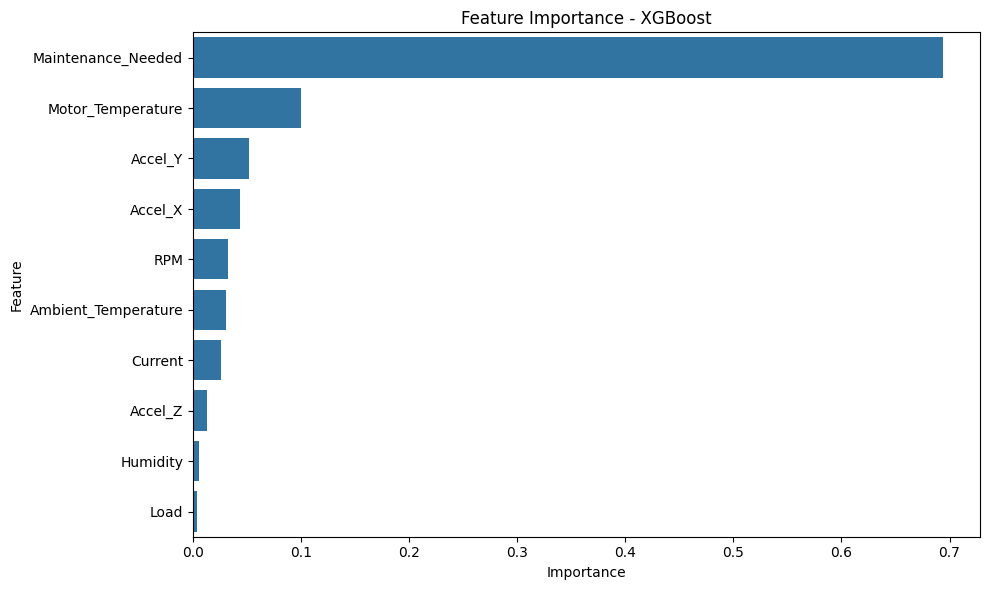

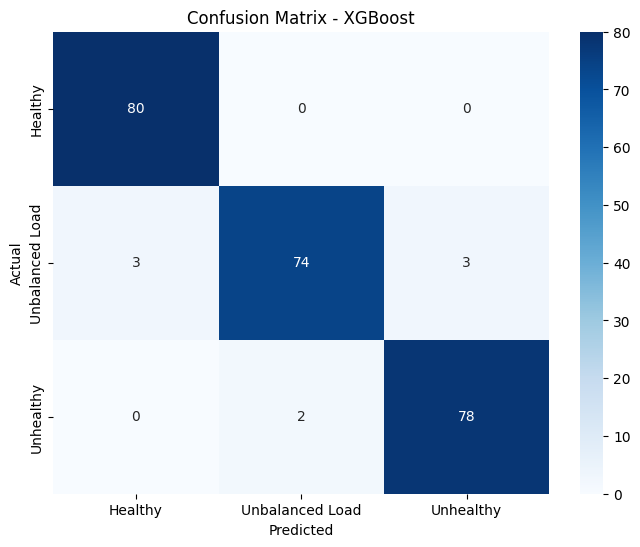


DIGITAL TWIN HEALTH PREDICTION
Predicted State: Unbalanced Load

Best model saved as:
best_predictive_maintenance_model.pkl


In [2]:
# ============================================================
# AI-Based Predictive Maintenance
# Model Comparison: Random Forest vs XGBoost vs LightGBM
# Target: Condition_Label
# Dataset: Predictive_Maintenance_Dataset_1200_Records.csv
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("Predictive_Maintenance_Dataset_1200_Records.csv")

print("\nDataset Shape:", df.shape)
print(df.head())

# ============================================================
# 2. ENCODE CATEGORICAL FEATURES
# ============================================================

label_encoders = {}

categorical_cols = [
    "Load",
    "Maintenance_Needed",
    "Condition_Label"
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# ============================================================
# 3. FEATURES & TARGET
# ============================================================

X = df.drop("Condition_Label", axis=1)
y = df["Condition_Label"]

print("\nFeatures:")
print(X.columns)

# ============================================================
# 4. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# ============================================================
# 5. RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print("\n==============================")
print("RANDOM FOREST RESULTS")
print("==============================")
print("Accuracy :", rf_acc)
print("F1 Score :", rf_f1)
print(classification_report(y_test, rf_pred))

# ============================================================
# 6. XGBOOST
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective='multi:softmax',
    num_class=len(np.unique(y)),
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred, average='weighted')

print("\n==============================")
print("XGBOOST RESULTS")
print("==============================")
print("Accuracy :", xgb_acc)
print("F1 Score :", xgb_f1)
print(classification_report(y_test, xgb_pred))

# ============================================================
# 7. LIGHTGBM
# ============================================================

lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)

lgbm_acc = accuracy_score(y_test, lgbm_pred)
lgbm_f1 = f1_score(y_test, lgbm_pred, average='weighted')

print("\n==============================")
print("LIGHTGBM RESULTS")
print("==============================")
print("Accuracy :", lgbm_acc)
print("F1 Score :", lgbm_f1)
print(classification_report(y_test, lgbm_pred))

# ============================================================
# 8. MODEL COMPARISON
# ============================================================

results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM"],
    "Accuracy": [rf_acc, xgb_acc, lgbm_acc],
    "F1 Score": [rf_f1, xgb_f1, lgbm_f1]
})

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")
print(results.sort_values(by="Accuracy", ascending=False))

# ============================================================
# 9. BEST MODEL SELECTION
# ============================================================

best_model_name = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

print("\nBest Model:", best_model_name)

if best_model_name == "Random Forest":
    best_model = rf_model
elif best_model_name == "XGBoost":
    best_model = xgb_model
else:
    best_model = lgbm_model

# ============================================================
# 10. FEATURE IMPORTANCE
# ============================================================

importances = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Important Features:")
print(feature_importance_df)

plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature"
)
plt.title(f"Feature Importance - {best_model_name}")
plt.tight_layout()
plt.show()

# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

if best_model_name == "Random Forest":
    best_pred = rf_pred
elif best_model_name == "XGBoost":
    best_pred = xgb_pred
else:
    best_pred = lgbm_pred

cm = confusion_matrix(y_test, best_pred)

class_names = label_encoders["Condition_Label"].classes_

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# ============================================================
# 12. DIGITAL TWIN HEALTH STATE PREDICTION EXAMPLE
# ============================================================

sample = pd.DataFrame([{
    "RPM": 100,
    "Current": 0.68,
    "Motor_Temperature": 53.2,
    "Ambient_Temperature": 28.0,
    "Humidity": 45.0,
    "Accel_X": -0.92,
    "Accel_Y": -0.44,
    "Accel_Z": 9.30,
    "Load": label_encoders["Load"].transform(["Moderate"])[0],
    "Maintenance_Needed": label_encoders["Maintenance_Needed"].transform(["Yes"])[0]
}])

prediction = best_model.predict(sample)

health_state = label_encoders["Condition_Label"].inverse_transform(prediction)

print("\n===================================")
print("DIGITAL TWIN HEALTH PREDICTION")
print("===================================")
print("Predicted State:", health_state[0])

# ============================================================
# OPTIONAL: SAVE BEST MODEL
# ============================================================

import joblib

joblib.dump(best_model, "best_predictive_maintenance_model.pkl")

print("\nBest model saved as:")
print("best_predictive_maintenance_model.pkl")